# Clasificación de audio sintético con CWT + CNN (y baseline RandomForest)

**Maestría en Ciencia de Datos — UANL** · Procesamiento y clasificación de datos

Experimento de prueba de concepto controlada: dataset sintético de 5 clases acústicas, usado para validar el pipeline completo (CWT → CNN vs. RandomForest) antes de correrlo contra audio real (`spoken_mnist`, notebook aparte).

Clases: `tono_puro`, `sirena`, `percusion`, `viento`, `campana`.

In [1]:
# Dependencias (Colab ya trae tensorflow/sklearn/matplotlib; solo falta pywavelets)
#!pip install -q PyWavelets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pywt
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

## 1. Generación del dataset sintético

Se generan 5 clases acústicas diseñadas para ocupar regiones distintas del plano tiempo-frecuencia, análogas a categorías de sonido reales (tono sostenido, sirena, percusión, viento, campana). Se añade ruido blanco aditivo con SNR aleatorio (3–15 dB) para simular condiciones de grabación no controladas y evitar un problema trivialmente separable.

In [3]:
SR = 8000          # frecuencia de muestreo (Hz)
DUR = 1.0           # duración de cada muestra (s)
N_SAMPLES_PER_CLASS = 80
RNG = np.random.default_rng(42)

CLASSES = ["tono_puro", "sirena", "percusion", "viento", "campana"]


def _t():
    return np.linspace(0, DUR, int(SR * DUR), endpoint=False)


def _adsr(n, attack=0.05, decay=0.15, sustain=0.6, release=0.2):
    a = int(n * attack)
    d = int(n * decay)
    r = int(n * release)
    s = n - a - d - r
    env = np.concatenate([
        np.linspace(0, 1, max(a, 1)),
        np.linspace(1, sustain, max(d, 1)),
        np.full(max(s, 1), sustain),
        np.linspace(sustain, 0, max(r, 1)),
    ])
    return env[:n]

In [4]:
def gen_tono_puro(rng):
    t = _t()
    f0 = rng.uniform(220, 700)
    sig = np.sin(2 * np.pi * f0 * t)
    sig += 0.3 * np.sin(2 * np.pi * 2 * f0 * t)
    sig += 0.15 * np.sin(2 * np.pi * 3 * f0 * t)
    sig *= _adsr(len(t))
    sig += rng.normal(0, 0.01, len(t))
    return sig


def gen_sirena(rng):
    t = _t()
    f_centro = rng.uniform(400, 700)
    f_mod = rng.uniform(1.5, 3.5)
    desviacion = rng.uniform(150, 300)
    inst_freq = f_centro + desviacion * np.sin(2 * np.pi * f_mod * t)
    fase = 2 * np.pi * np.cumsum(inst_freq) / SR
    sig = np.sin(fase)
    sig *= 0.9
    sig += rng.normal(0, 0.01, len(t))
    return sig


def gen_percusion(rng):
    n = int(SR * DUR)
    t = _t()
    tau = rng.uniform(0.06, 0.15)
    envolvente = np.exp(-t / tau)
    ruido = rng.normal(0, 1, n)
    freqs = np.fft.rfftfreq(n, d=1 / SR)
    f_centro = rng.uniform(80, 250)
    ancho = rng.uniform(60, 150)
    filtro = np.exp(-0.5 * ((freqs - f_centro) / ancho) ** 2)
    ruido_f = np.fft.irfft(np.fft.rfft(ruido) * filtro, n)
    click = np.zeros(n)
    click[: int(SR * 0.002)] = 1.0
    sig = (0.7 * ruido_f / (np.abs(ruido_f).max() + 1e-9) + 0.5 * click) * envolvente
    return sig


def gen_viento(rng):
    n = int(SR * DUR)
    t = _t()
    ruido = rng.normal(0, 1, n)
    freqs = np.fft.rfftfreq(n, d=1 / SR)
    f_centro = rng.uniform(300, 900)
    ancho = rng.uniform(200, 400)
    filtro = np.exp(-0.5 * ((freqs - f_centro) / ancho) ** 2)
    ruido_f = np.fft.irfft(np.fft.rfft(ruido) * filtro, n)
    ruido_f /= np.abs(ruido_f).max() + 1e-9
    f_gust = rng.uniform(0.5, 1.5)
    mod = 0.5 + 0.5 * np.sin(2 * np.pi * f_gust * t + rng.uniform(0, np.pi))
    sig = 0.8 * ruido_f * mod
    return sig


def gen_campana(rng):
    t = _t()
    f0 = rng.uniform(300, 500)
    parciales = [1.0, 1.79, 2.4, 3.12, 4.05]
    sig = np.zeros(len(t))
    for i, ratio in enumerate(parciales):
        tau = rng.uniform(0.25, 0.6) / (i + 1) + 0.15
        amp = 1.0 / (i + 1)
        sig += amp * np.sin(2 * np.pi * f0 * ratio * t) * np.exp(-t / tau)
    sig /= np.abs(sig).max() + 1e-9
    sig += rng.normal(0, 0.005, len(t))
    return sig


GENERATORS = {
    "tono_puro": gen_tono_puro,
    "sirena": gen_sirena,
    "percusion": gen_percusion,
    "viento": gen_viento,
    "campana": gen_campana,
}

In [5]:
def _add_ruido_snr(sig, snr_db, rng):
    """Añade ruido blanco aditivo a una relación señal/ruido (SNR) dada en dB,
    para simular condiciones de grabación no ideales."""
    potencia_senal = np.mean(sig ** 2) + 1e-12
    potencia_ruido = potencia_senal / (10 ** (snr_db / 10))
    ruido = rng.normal(0, np.sqrt(potencia_ruido), len(sig))
    return sig + ruido


def build_dataset(snr_range=(3, 15)):
    X, y = [], []
    for label_idx, clase in enumerate(CLASSES):
        gen_fn = GENERATORS[clase]
        for _ in range(N_SAMPLES_PER_CLASS):
            sig = gen_fn(RNG)
            snr_db = RNG.uniform(*snr_range)
            sig = _add_ruido_snr(sig, snr_db, RNG)
            X.append(sig.astype(np.float32))
            y.append(label_idx)
    X = np.array(X)
    y = np.array(y)
    print(f"Dataset generado: {X.shape[0]} muestras, {X.shape[1]} puntos c/u, {len(CLASSES)} clases")
    return X, y


X_audio, y_labels = build_dataset()

Dataset generado: 400 muestras, 8000 puntos c/u, 5 clases


## 2. Formas de onda y espectrogramas (STFT) por clase

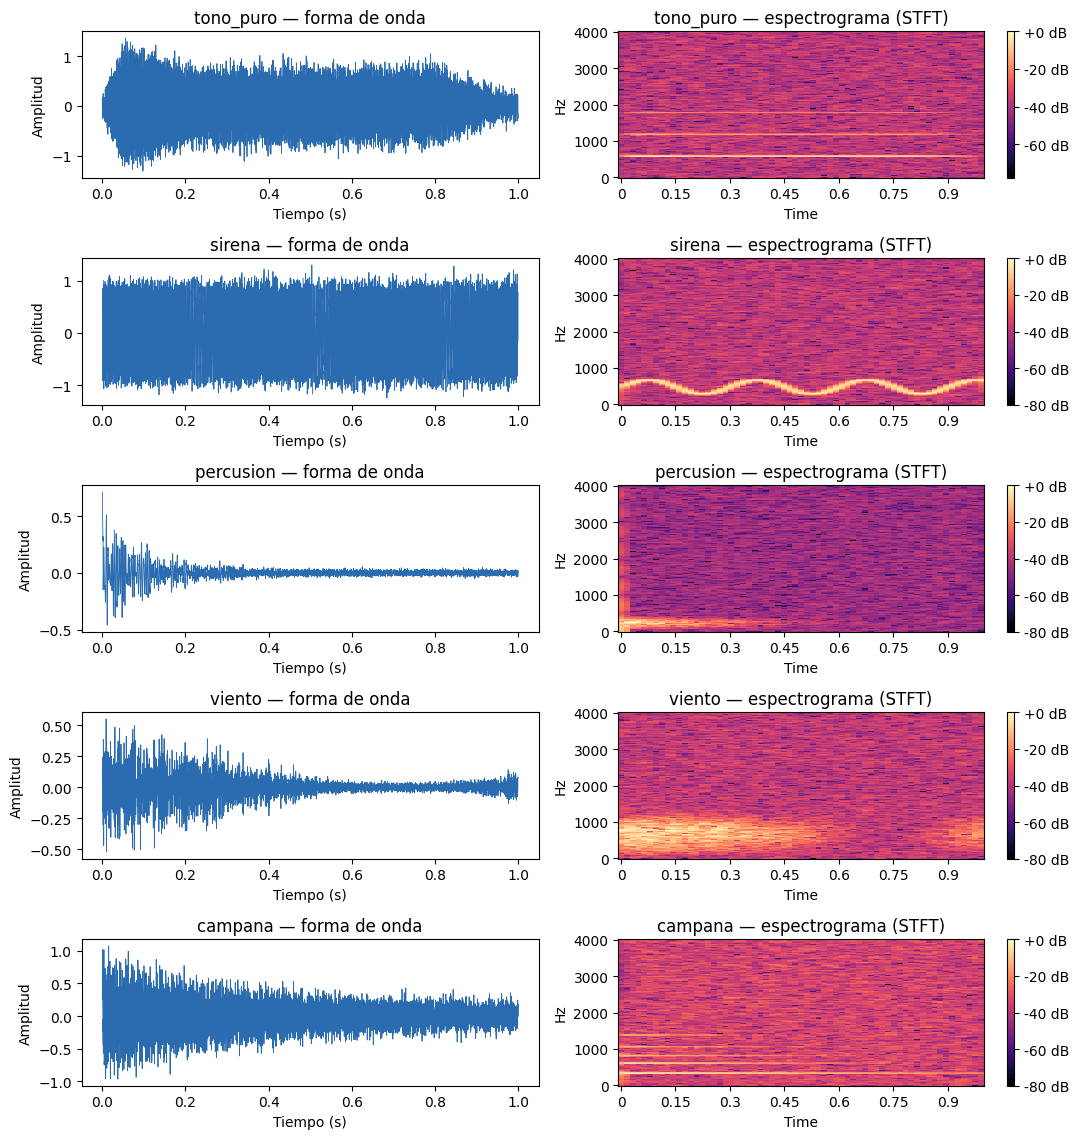

In [6]:
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(11, 2.3 * len(CLASSES)))

for i, clase in enumerate(CLASSES):
    idx = np.where(y_labels == i)[0][0]
    sig = X_audio[idx]

    axes[i, 0].plot(np.linspace(0, 1, len(sig)), sig, linewidth=0.6, color="#2b6cb0")
    axes[i, 0].set_title(f"{clase} — forma de onda")
    axes[i, 0].set_xlabel("Tiempo (s)")
    axes[i, 0].set_ylabel("Amplitud")

    S = librosa.stft(sig, n_fft=512, hop_length=128)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    img = librosa.display.specshow(S_db, sr=SR, hop_length=128, x_axis="time", y_axis="linear", ax=axes[i, 1], cmap="magma")
    axes[i, 1].set_title(f"{clase} — espectrograma (STFT)")
    fig.colorbar(img, ax=axes[i, 1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("01_ejemplos_por_clase.png", dpi=130)
plt.show()

## 3. Extracción de features — Transformada Wavelet Continua (CWT)

Ondícula compleja de Morlet (`cmor1.5-1.0`), 64 escalas log-espaciadas cubriendo 40–2000 Hz. Se toma la magnitud de los coeficientes (scalograma), se comprime con `log1p` (análogo a usar dB) y se reescala a 64×64.

In [7]:
WAVELET = "cmor1.5-1.0"
N_SCALES = 64
IMG_SIZE = (64, 64)
FREQ_MIN, FREQ_MAX = 40, 2000

_central_freq = pywt.central_frequency(WAVELET)
_scale_min = _central_freq * SR / FREQ_MAX
_scale_max = _central_freq * SR / FREQ_MIN
SCALES = np.geomspace(_scale_min, _scale_max, N_SCALES)


def signal_to_scalogram(sig):
    coef, _freqs = pywt.cwt(sig, SCALES, WAVELET, sampling_period=1 / SR)
    mag = np.abs(coef)
    mag = np.log1p(mag)
    zoom_factors = (IMG_SIZE[0] / mag.shape[0], IMG_SIZE[1] / mag.shape[1])
    img = zoom(mag, zoom_factors, order=1)
    img = (img - img.min()) / (img.max() - img.min() + 1e-9)
    return img.astype(np.float32)


X_scalograms = np.zeros((len(X_audio), *IMG_SIZE, 1), dtype=np.float32)
for i, sig in enumerate(X_audio):
    X_scalograms[i, :, :, 0] = signal_to_scalogram(sig)

print(f"Scalogramas generados: {X_scalograms.shape}")

Scalogramas generados: (400, 64, 64, 1)


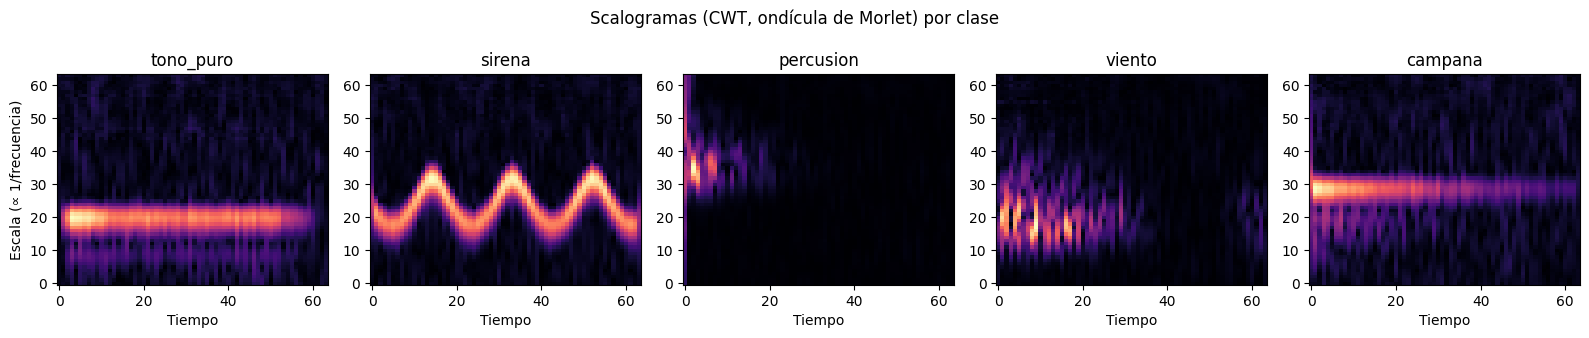

In [8]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(3.2 * len(CLASSES), 3.4))
for i, clase in enumerate(CLASSES):
    idx = np.where(y_labels == i)[0][0]
    axes[i].imshow(X_scalograms[idx, :, :, 0], aspect="auto", origin="lower", cmap="magma")
    axes[i].set_title(clase)
    axes[i].set_xlabel("Tiempo")
    if i == 0:
        axes[i].set_ylabel("Escala (∝ 1/frecuencia)")

plt.suptitle("Scalogramas (CWT, ondícula de Morlet) por clase")
plt.tight_layout()
plt.savefig("02_scalogramas_por_clase.png", dpi=130)
plt.show()

## 4. Modelo 1 — CNN sobre el scalograma completo

3 bloques Conv2D (16→32→64 filtros) con max-pooling, *global average pooling*, densa de 32 con dropout 0.3, softmax de 5 clases.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scalograms, y_labels, test_size=0.25, random_state=42, stratify=y_labels
)

model = keras.Sequential([
    keras.layers.Input(shape=X_scalograms.shape[1:]),
    keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(len(CLASSES), activation="softmax"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    verbose=2,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,541 (99.77 KB)

 Trainable params: 25,541 (99.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
15/15 - 1s - 97ms/step - accuracy: 0.1667 - loss: 1.6019 - val_accuracy: 0.2333 - val_loss: 1.5694
Epoch 2/30
15/15 - 0s - 17ms/step - accuracy: 0.2250 - loss: 1.5547 - val_accuracy: 0.2333 - val_loss: 1.4963
Epoch 3/30
15/15 - 0s - 15ms/step - accuracy: 0.1750 - loss: 1.5233 - val_accuracy: 0.2333 - val_loss: 1.4527
Epoch 4/30
15/15 - 0s - 15ms/step - accuracy: 0.2542 - loss: 1.4607 - val_accuracy: 0.4667 - val_loss: 1.3932
Epoch 5/30
15/15 - 0s - 14ms/step - accuracy: 0.4083 - loss: 1.4075 - val_accuracy: 0.6500 - val_loss: 1.3121
Epoch 6/30
15/15 - 0s - 16ms/step - accuracy: 0.5458 - loss: 1.2743 - val_accuracy: 0.6167 - val_loss: 1.1737
Epoch 7/30
15/15 - 0s - 15ms/step - accuracy: 0.6000 - loss: 1.1206 - val_accuracy: 0.7667 - val_loss: 0.9098
Epoch 8/30
15/15 - 0s - 15ms/step - accuracy: 0.6375 - loss: 0.9672 - val_accuracy: 0.8000 - val_loss: 0.7017
Epoch 9/30
15/15 - 0s - 16ms/step - accuracy: 0.6583 - loss: 0.8271 - val_accuracy: 0.7333 - val_loss: 0.6470
Epoch 10/3


Accuracy en test (CNN): 1.0000
              precision    recall  f1-score   support

   tono_puro      1.000     1.000     1.000        20
      sirena      1.000     1.000     1.000        20
   percusion      1.000     1.000     1.000        20
      viento      1.000     1.000     1.000        20
     campana      1.000     1.000     1.000        20

    accuracy                          1.000       100
   macro avg      1.000     1.000     1.000       100
weighted avg      1.000     1.000     1.000       100



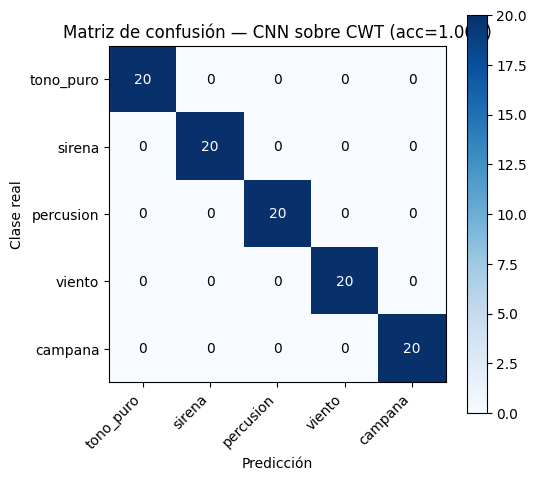

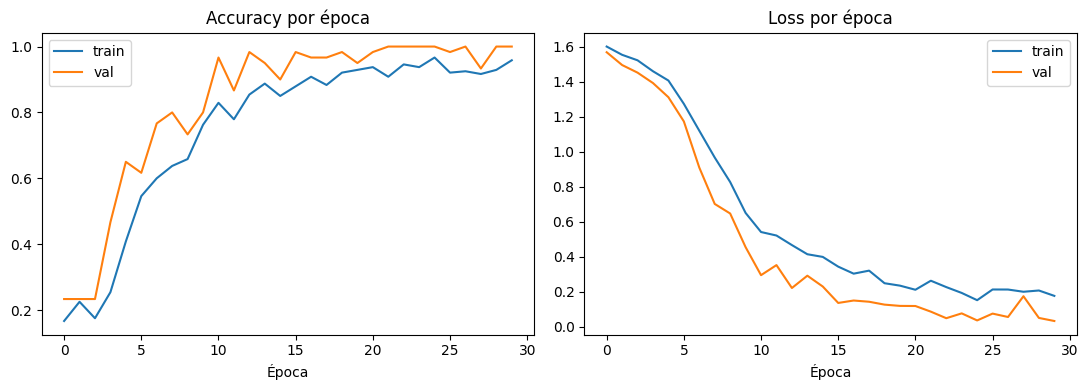

In [10]:
test_loss, test_acc_cnn = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAccuracy en test (CNN): {test_acc_cnn:.4f}")

y_pred_cnn = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred_cnn, target_names=CLASSES, digits=3))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_cnn, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicción"); ax.set_ylabel("Clase real")
ax.set_title(f"Matriz de confusión — CNN sobre CWT (acc={test_acc_cnn:.3f})")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm_cnn[i, j], ha="center", va="center",
                 color="white" if cm_cnn[i, j] > cm_cnn.max() / 2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("03_matriz_confusion_cnn.png", dpi=130)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy por época"); axes[0].set_xlabel("Época"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss por época"); axes[1].set_xlabel("Época"); axes[1].legend()
plt.tight_layout()
plt.savefig("04_curvas_entrenamiento_cnn.png", dpi=130)
plt.show()

## 5. Modelo 2 — Baseline clásico (RandomForest sobre features estadísticas de la CWT)

En vez de darle el scalograma completo a una CNN, se resume cada una de las 64 bandas de escala con 4 estadísticos (media, std, máximo, energía) → vector de 256 features por muestra, y se entrena un RandomForest. Se usa la misma partición train/test que la CNN.

Accuracy en test (RandomForest sobre features de CWT): 1.0000
              precision    recall  f1-score   support

   tono_puro      1.000     1.000     1.000        20
      sirena      1.000     1.000     1.000        20
   percusion      1.000     1.000     1.000        20
      viento      1.000     1.000     1.000        20
     campana      1.000     1.000     1.000        20

    accuracy                          1.000       100
   macro avg      1.000     1.000     1.000       100
weighted avg      1.000     1.000     1.000       100



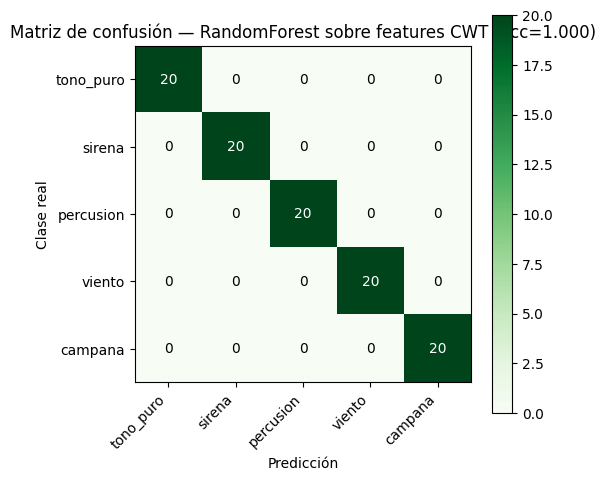

In [11]:
S = X_scalograms[..., 0]  # (N, escalas, tiempo)

feats = np.concatenate([
    S.mean(axis=2),
    S.std(axis=2),
    S.max(axis=2),
    (S ** 2).sum(axis=2),
], axis=1)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    feats, y_labels, test_size=0.25, random_state=42, stratify=y_labels
)

clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(Xf_train, yf_train)
y_pred_rf = clf.predict(Xf_test)
test_acc_rf = accuracy_score(yf_test, y_pred_rf)
print(f"Accuracy en test (RandomForest sobre features de CWT): {test_acc_rf:.4f}")
print(classification_report(yf_test, y_pred_rf, target_names=CLASSES, digits=3))

cm_rf = confusion_matrix(yf_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_rf, cmap="Greens")
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicción"); ax.set_ylabel("Clase real")
ax.set_title(f"Matriz de confusión — RandomForest sobre features CWT (acc={test_acc_rf:.3f})")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm_rf[i, j], ha="center", va="center",
                 color="white" if cm_rf[i, j] > cm_rf.max() / 2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("05_matriz_confusion_baseline.png", dpi=130)
plt.show()

## 6. Resumen comparativo

Copia estos resultados al reporte en Markdown si difieren de los que ya tienes (con `random_state=42` deberían salir iguales, pero por si tu entorno usa otra versión de librosa/pywt/sklearn/tensorflow y hay pequeñas diferencias numéricas).

In [12]:
print(f"CNN sobre scalograma (CWT):              {test_acc_cnn:.4f}")
print(f"RandomForest sobre features de CWT:       {test_acc_rf:.4f}")

CNN sobre scalograma (CWT):              1.0000
RandomForest sobre features de CWT:       1.0000
